   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 36.1 MB/s eta 0:00:00
Kết quả
Mức giá vé đề xuất: 12.67%
Điểm thưởng cho tài xế: 35.00 điểm


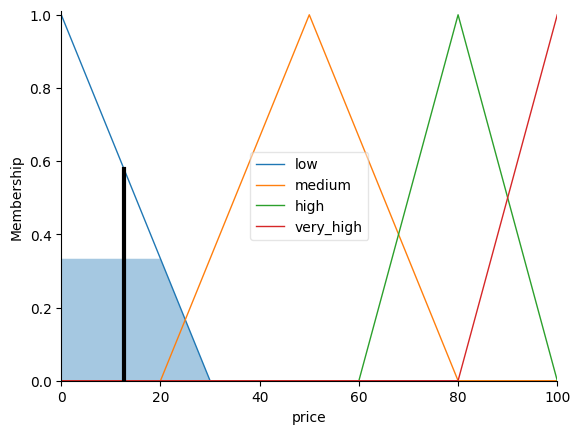

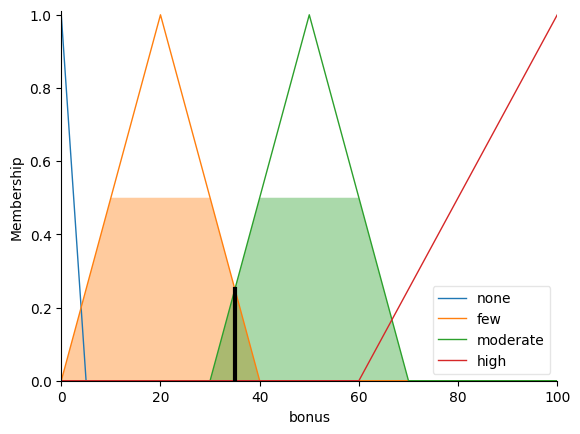

In [ ]:
!pip install scikit-fuzzy
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

khoang_cach = ctrl.Antecedent(np.arange(0, 51, 1), 'distance')
giao_thong = ctrl.Antecedent(np.arange(0, 101, 1), 'traffic')
nhu_cau = ctrl.Antecedent(np.arange(0, 101, 1), 'demand')
thoi_tiet = ctrl.Antecedent(np.arange(0, 11, 1), 'weather')
danh_gia = ctrl.Antecedent(np.arange(1, 5.1, 0.1), 'rating')
dung_gio = ctrl.Antecedent(np.arange(0, 101, 1), 'punctuality')


gia_ca = ctrl.Consequent(np.arange(0, 101, 1), 'price')
diem_thuong = ctrl.Consequent(np.arange(0, 101, 1), 'bonus')


khoang_cach['short'] = fuzz.trimf(khoang_cach.universe, [0, 0, 3])
khoang_cach['medium'] = fuzz.trimf(khoang_cach.universe, [2, 4.5, 7])
khoang_cach['long'] = fuzz.trimf(khoang_cach.universe, [6, 13, 20])
khoang_cach['very_long'] = fuzz.trimf(khoang_cach.universe, [15, 50, 50])

giao_thong['low'] = fuzz.trimf(giao_thong.universe, [0, 0, 30])
giao_thong['medium'] = fuzz.trimf(giao_thong.universe, [20, 45, 70])
giao_thong['high'] = fuzz.trimf(giao_thong.universe, [60, 100, 100])

nhu_cau['low'] = fuzz.trimf(nhu_cau.universe, [0, 0, 30])
nhu_cau['medium'] = fuzz.trimf(nhu_cau.universe, [20, 45, 70])
nhu_cau['high'] = fuzz.trimf(nhu_cau.universe, [60, 100, 100])

thoi_tiet['good'] = fuzz.trimf(thoi_tiet.universe, [0, 0, 4])
thoi_tiet['moderate'] = fuzz.trimf(thoi_tiet.universe, [3, 5, 7])
thoi_tiet['bad'] = fuzz.trimf(thoi_tiet.universe, [6, 10, 10])

danh_gia['poor'] = fuzz.trimf(danh_gia.universe, [1, 1, 2.5])
danh_gia['average'] = fuzz.trimf(danh_gia.universe, [2.5, 3.25, 4.0])
danh_gia['good'] = fuzz.trimf(danh_gia.universe, [3.5, 5.0, 5.0])

dung_gio['late'] = fuzz.trimf(dung_gio.universe, [0, 0, 50])
dung_gio['on_time'] = fuzz.trimf(dung_gio.universe, [40, 60, 80])
dung_gio['early'] = fuzz.trimf(dung_gio.universe, [70, 100, 100])

gia_ca['low'] = fuzz.trimf(gia_ca.universe, [0, 0, 30])
gia_ca['medium'] = fuzz.trimf(gia_ca.universe, [20, 50, 80])
gia_ca['high'] = fuzz.trimf(gia_ca.universe, [60, 80, 100])
gia_ca['very_high'] = fuzz.trimf(gia_ca.universe, [80, 100, 100])

diem_thuong['none'] = fuzz.trimf(diem_thuong.universe, [0, 0, 5])
diem_thuong['few'] = fuzz.trimf(diem_thuong.universe, [0, 20, 40])
diem_thuong['moderate'] = fuzz.trimf(diem_thuong.universe, [30, 50, 70])
diem_thuong['high'] = fuzz.trimf(diem_thuong.universe, [60, 100, 100])

rule1 = ctrl.Rule(khoang_cach['short'] & giao_thong['low'] & nhu_cau['low'], gia_ca['low'])
rule2 = ctrl.Rule(khoang_cach['short'] & giao_thong['medium'] & nhu_cau['high'], gia_ca['medium'])
rule3 = ctrl.Rule(khoang_cach['medium'] & giao_thong['high'] & nhu_cau['high'], gia_ca['high'])
rule4 = ctrl.Rule(khoang_cach['long'] & giao_thong['medium'] & thoi_tiet['good'], gia_ca['medium'])
rule5 = ctrl.Rule(khoang_cach['long'] & giao_thong['high'] & thoi_tiet['bad'], gia_ca['very_high'])
rule6 = ctrl.Rule(khoang_cach['very_long'] & giao_thong['high'] & nhu_cau['high'], gia_ca['very_high'])
rule7 = ctrl.Rule(khoang_cach['medium'] & giao_thong['low'] & nhu_cau['low'], gia_ca['medium'])
rule8 = ctrl.Rule(khoang_cach['short'] & giao_thong['high'] & thoi_tiet['bad'], gia_ca['high'])
rule9 = ctrl.Rule(khoang_cach['very_long'] & thoi_tiet['bad'], gia_ca['very_high'])
rule10 = ctrl.Rule(khoang_cach['medium'] & giao_thong['medium'] & thoi_tiet['moderate'], gia_ca['medium'])

rule11 = ctrl.Rule(danh_gia['good'] & dung_gio['early'], diem_thuong['high'])
rule12 = ctrl.Rule(danh_gia['average'] & dung_gio['on_time'], diem_thuong['moderate'])
rule13 = ctrl.Rule(danh_gia['poor'] & dung_gio['late'], diem_thuong['none'])
rule14 = ctrl.Rule(khoang_cach['long'] & giao_thong['high'] & dung_gio['on_time'], diem_thuong['high'])
rule15 = ctrl.Rule(khoang_cach['medium'] & giao_thong['medium'] & danh_gia['good'], diem_thuong['moderate'])
rule17 = ctrl.Rule(khoang_cach['very_long'] & thoi_tiet['bad'] & danh_gia['good'], diem_thuong['high'])
rule18 = ctrl.Rule(khoang_cach['short'] & danh_gia['average'] & dung_gio['on_time'], diem_thuong['few'])
rule19 = ctrl.Rule(khoang_cach['long'] & giao_thong['high'] & dung_gio['late'], diem_thuong['few'])
rule20 = ctrl.Rule(khoang_cach['medium'] & thoi_tiet['moderate'] & danh_gia['good'], diem_thuong['moderate'])


grab_ctrl = ctrl.ControlSystem([
    rule1, rule2, rule3, rule4, rule5, rule6, rule7, rule8, rule9, rule10,
    rule11, rule12, rule13, rule14, rule15, rule17, rule18, rule19, rule20
])

grab_simulation = ctrl.ControlSystemSimulation(grab_ctrl)

grab_simulation.input['distance'] = 1
grab_simulation.input['traffic'] = 10
grab_simulation.input['demand'] = 20
grab_simulation.input['weather'] = 2
grab_simulation.input['rating'] = 3.5
grab_simulation.input['punctuality'] = 70


grab_simulation.compute()


print("Kết quả")
print(f"Mức giá vé đề xuất: {grab_simulation.output['price']:.2f}%")
print(f"Điểm thưởng cho tài xế: {grab_simulation.output['bonus']:.2f} điểm")


gia_ca.view(sim=grab_simulation)
diem_thuong.view(sim=grab_simulation)
